Creamos un modelo de regresión lineal para predecir la nota final.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import joblib

pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv('df_regresion.csv', index_col=0)
df.head()

,horas_estudio_semanal,nota_anterior,tasa_asistencia,horas_sueno,edad,horario_estudio_preferido,estilo_aprendizaje,nota_final,aprobado,nivel_dificultad_Difícil,nivel_dificultad_Fácil,nivel_dificultad_Medio,tiene_tutor_No,tiene_tutor_Sí
0,0.331561,0.269009,0.833002,0.445949,0.636364,0.577230,1.000000,84.4,1.0,0.0,1.0,0.0,0.0,1.0
1,0.418439,0.726082,0.793121,0.102807,0.000000,0.577230,0.000000,72.0,1.0,1.0,0.0,0.0,1.0,0.0
2,0.146282,0.862624,0.682795,0.625874,0.636364,0.505606,1.000000,80.0,1.0,0.0,1.0,0.0,1.0,0.0
3,0.235301,0.741118,0.785623,0.765471,0.454545,1.000000,0.449354,78.2,1.0,0.0,1.0,0.0,1.0,0.0
4,0.000000,0.517917,0.431749,0.445307,0.272727,1.000000,0.792851,66.0,1.0,0.0,0.0,1.0,1.0,0.0


Separamos la variable objetivo.

In [3]:
tv = 'nota_final'

X = df.drop(columns=[tv,'aprobado']) # Quitamos la columna objetivo y la columna aprobado.
y = df[tv]

Creamos el conjunto de entrenamiento y el conjunto de prueba.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Creamos el modelo y lo entrenamos con el conjunto de entrenamiento.

In [5]:
modelo = LinearRegression()

In [6]:
modelo.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Hacemos las predicciones con el conjunto de prueba.

In [7]:
y_pred = modelo.predict(X_test)

Creamos un grafico de dispersión para ver los resultados.

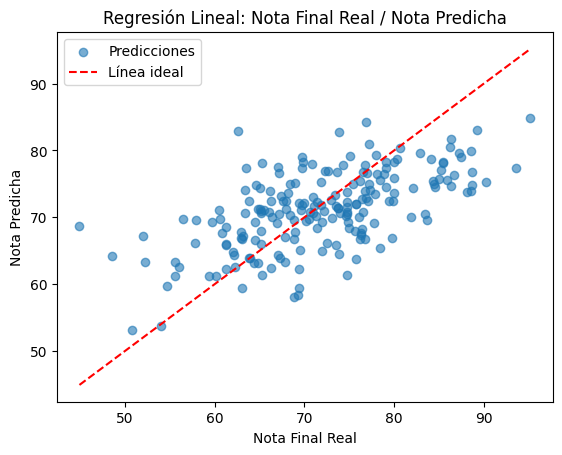

In [8]:
plt.scatter(y_test, y_pred, label="Predicciones", alpha=0.6)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", label="Línea ideal")
plt.xlabel("Nota Final Real")
plt.ylabel("Nota Predicha")
plt.title("Regresión Lineal: Nota Final Real / Nota Predicha")
plt.legend()
plt.show()

Graficamos los residuos.

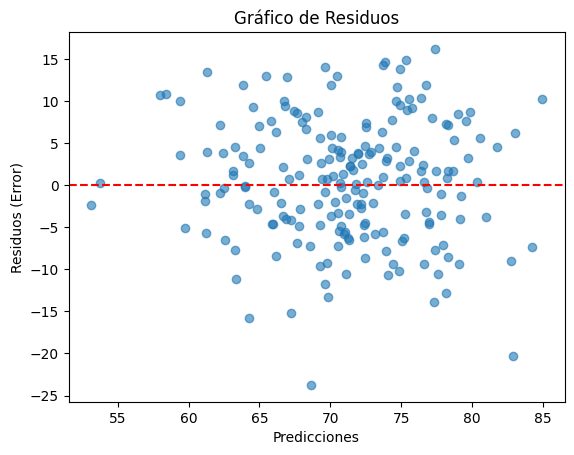

In [9]:
residuos = y_test - y_pred

plt.scatter(y_pred, residuos, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicciones")
plt.ylabel("Residuos (Error)")
plt.title("Gráfico de Residuos")
plt.show()

Vamos a ver la importancia de cada caracterista en la predicción.

In [10]:
coef_df = pd.DataFrame({'Caracteristica': X.columns.to_list(), 'Coeficiente': modelo.coef_})
coef_df = coef_df.sort_values(by='Coeficiente', ascending=False, key=abs)
coef_df

,Caracteristica,Coeficiente
0,horas_estudio_semanal,16.921216
1,nota_anterior,11.683295
2,tasa_asistencia,7.304136
6,estilo_aprendizaje,1.743872
7,nivel_dificultad_Difícil,-1.583943
8,nivel_dificultad_Fácil,1.515570
5,horario_estudio_preferido,0.774300
4,edad,0.422383
3,horas_sueno,-0.340978
11,tiene_tutor_Sí,0.323854


Creamos un grafico para verlo.

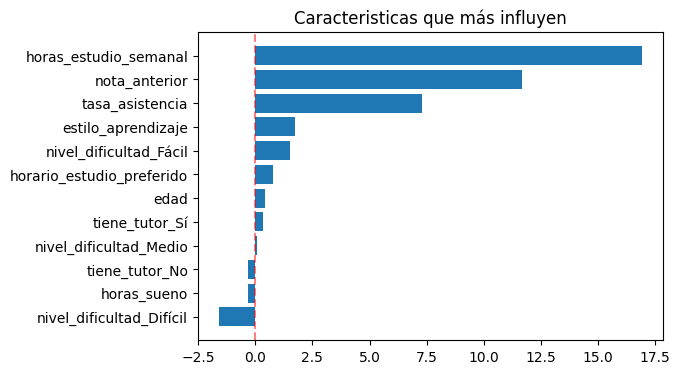

In [23]:
coef_df = coef_df.sort_values(by='Coeficiente') # Lo reordenamos para verlo mejor.
plt.figure(figsize=(6,4))
plt.barh(coef_df['Caracteristica'], coef_df['Coeficiente'])
plt.axvline(x=0, color='red', linestyle='--', alpha=0.5)
plt.title('Caracteristicas que más influyen')
plt.show()

Calculamos las metricas R2 MAE y RMSE

In [25]:
y_train_pred = modelo.predict(X_train) # Utilizamos el modelo para que prediga con las que entreno.
y_test_pred = modelo.predict(X_test)

In [34]:
r2_e = r2_score(y_train, y_train_pred)
MAE_e = mean_absolute_error(y_train, y_train_pred)
RMSE_e = np.sqrt(mean_squared_error(y_train, y_train_pred))

r2_t = r2_score(y_test, y_test_pred)
MAE_t = mean_absolute_error(y_test, y_test_pred)
RMSE_t = np.sqrt(mean_squared_error(y_test, y_test_pred))

df_metricas = pd.DataFrame({
    'Entrenamiento': [r2_e, MAE_e, RMSE_e],
    'Prueba': [r2_t, MAE_t, RMSE_t]
}, index=['R2', 'MAE', 'RMSE']).round(2)

df_metricas


,Entrenamiento,Prueba
R2,0.39,0.36
MAE,6.02,5.81
RMSE,7.57,7.21


Entrenamos el modelo con todos los datos y lo guardamos

In [ ]:
modelo_final = LinearRegression()
modelo_final.fit(X, y)


joblib.dump(modelo_final, "modelo_regresion.pkl")

['modelo_regresion.pkl']